# 01 — Exploratory Data Analysis (EDA)

**Dataset:** Inside Airbnb — New York City (open data, insideairbnb.com)  
**Goal:** Predict the total number of **blocked nights in Q1 2026** (Jan–Mar) for NYC Airbnb listings.  
**Metric:** Mean Squared Error (MSE) — lower is better.  
**Training period:** Q3 2025 (Jul–Sep) + Q4 2025 (Oct–Dec)  
**Prediction period:** Q1 2026 (Jan–Mar)

---

## Notebook Outline
1. Setup & Imports
2. Data Paths & Directory Overview
3. Load Raw Data (December 2025 Snapshot)
4. Dataset Shape & Column Overview
5. Target Variable — `blocked_days_Q1_2026` (naive first pass + 5.1 snapshot-agreement audit)
6. Calendar Data Exploration
7. Merged Feature Set & Correlations
8. Categorical & Geographic Analysis
10. Listing Coverage Across All 6 Months
11. Price Coverage — Source Decision
12. Property Type Taxonomy — New Schema
13. `amenities` Field — Key Binary Flags
14. `bathrooms_text` — Parsing to Numeric
15. Review Velocity from `reviews.csv`
16. `availability_*` vs Target — Dedicated Analysis
17. Key Findings & Next Steps

## 1. Setup & Imports

In [76]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('NumPy :', np.__version__)
print('Pandas:', pd.__version__)

NumPy : 2.4.6
Pandas: 3.0.3


## 2. Data Paths & Directory Overview

In [77]:
BASE_DIR = Path('../AirBnb_Inside')
Q3_DIR   = BASE_DIR / '2025_Inside_Airbnb/Q3'
Q4_DIR   = BASE_DIR / '2025_Inside_Airbnb/Q4'
Q1_DIR   = BASE_DIR / '2026_Inside_Airbnb'
OUT_DIR  = Path('../outputs')
OUT_DIR.mkdir(exist_ok=True, parents=True)

print('BASE_DIR :', BASE_DIR.resolve())
print()
print('Q3 2025 months :', sorted([p.name for p in Q3_DIR.iterdir() if p.is_dir()]))
print('Q4 2025 months :', sorted([p.name for p in Q4_DIR.iterdir() if p.is_dir()]))
print('2026 months    :', sorted([p.name for p in Q1_DIR.iterdir() if p.is_dir()]))

BASE_DIR : /Users/bashkal/Desktop/ML/ML-Final/Internship/AirBnb_Inside

Q3 2025 months : ['August2025', 'July2025', 'September2025']
Q4 2025 months : ['December2025', 'November2025', 'October2025']
2026 months    : ['April2026', 'February2026', 'January2026', 'March2026']


In [78]:
def detailed_listings_path(month_dir):
    """Return path of the detailed (79+ col) listings file.
    Inside Airbnb alternates listings.csv / listings-2.csv for the detailed file across months.
    """
    for fname in ['listings.csv', 'listings-2.csv']:
        p = Path(month_dir) / fname
        with open(p) as f:
            ncols = len(f.readline().split(','))
        if ncols > 30:
            return p
    raise FileNotFoundError(f'No detailed listings file in {month_dir}')

print(f'{"Month":<10} {"File":<16} {"Cols":>5} {"Listings":>10}')
print('-' * 46)
for label, month_dir in [
    ('Jul-25', Q3_DIR / 'July2025'),
    ('Aug-25', Q3_DIR / 'August2025'),
    ('Sep-25', Q3_DIR / 'September2025'),
    ('Oct-25', Q4_DIR / 'October2025'),
    ('Nov-25', Q4_DIR / 'November2025'),
    ('Dec-25', Q4_DIR / 'December2025'),
]:
    p = detailed_listings_path(month_dir)
    with open(p) as f:
        ncols = len(f.readline().split(','))
        nrows = sum(1 for _ in f)
    print(f'{label:<10} {p.name:<16} {ncols:>5} {nrows:>10,}')

Month      File              Cols   Listings
----------------------------------------------
Jul-25     listings-2.csv      79     77,580
Aug-25     listings.csv        79     77,897
Sep-25     listings.csv        79     65,198
Oct-25     listings-2.csv      79     64,858
Nov-25     listings.csv        79     64,286
Dec-25     listings.csv        85     59,098


## 3. Load Raw Data — December 2025 Snapshot

We use the **December 2025** scrape as our primary metadata source because:
- It is the most recent snapshot before the Q1 2026 prediction window
- Its calendar covers all of Q1 2026, giving us our target labels
- It has the richest schema (85 columns, including host-tenure fields added in late 2025)

> **Key schema difference from old Kaggle data:**  
> Old data had `Status ∈ {A, B, R}` (available / booked / host-blocked separately).  
> Inside Airbnb uses `available ∈ {t, f}` — blocked combines booked and host-blocked into one flag.

In [79]:
DEC_DIR = Q4_DIR / 'December2025'
dec_file = detailed_listings_path(DEC_DIR)
print(f'Loading: {dec_file.name}')

listings = pd.read_csv(dec_file, low_memory=False)
print(f'Shape: {listings.shape}')
listings.head(3)

Loading: listings.csv
Shape: (36261, 85)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,...,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20251204025441,2025-12-06,previous scrape,Superfast Wi-Fi. Clean & quiet home by the park,"Bright, serene room in a renovated apartment h...",Close to Prospect Park and Historic Ditmas Park,https://a0.muscache.com/pictures/hosting/Hosti...,2787,https://www.airbnb.com/users/show/2787,1.462506e+18,https://www.airbnb.com/users/profile/146250632...,John,2008-09-07,17.0,2.0,14.0,11.0,"New York, NY",Educated professional living in Brooklyn. I l...,within an hour,100%,79%,f,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Gravesend,7.0,13.0,...,NaN,t,30,60,90,364,2025-12-06,9,0,0,26,0,0,NaN,2015-12-04,2018-10-19,4.89,4.88,5.00,5.00,5.0,4.75,4.88,NaN,f,7,1,6,0,0.07
1,2595,https://www.airbnb.com/rooms/2595,20251204025441,2025-12-05,city scrape,Skylit Studio Oasis | Midtown Manhattan Sanctuary,Prime Midtown | Spacious 500 Sq Ft | Pyramid S...,Centrally located in the heart of Manhattan ju...,https://a0.muscache.com/pictures/hosting/Hosti...,2845,https://www.airbnb.com/users/show/2845,1.462506e+18,https://www.airbnb.com/users/profile/146250632...,Jennifer,2008-09-09,17.0,2.0,14.0,11.0,"Woodstock, NY",A New Yorker since 2000! My passion is creatin...,within a day,60%,26%,f,https://a0.muscache.com/im/pictures/user/50fc5...,https://a0.muscache.com/im/pictures/user/50fc5...,Midtown,7.0,9.0,...,NaN,t,30,60,90,319,2025-12-05,47,0,0,27,0,0,NaN,2009-11-21,2022-06-21,4.68,4.73,4.63,4.77,4.8,4.81,4.40,NaN,f,3,3,0,0,0.24
2,6848,https://www.airbnb.com/rooms/6848,20251204025441,2025-12-04,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,https://www.airbnb.com/users/show/15991,1.462507e+18,https://www.airbnb.com/users/profile/146250678...,Allen,2009-05-06,16.0,6.0,14.0,11.0,"New York, NY",We love to travel. When we travel we like to s...,within an hour,100%,100%,t,https://a0.muscache.com/im/users/15991/profile...,https://a0.muscache.com/im/users/15991/profile...,Williamsburg,1.0,1.0,...,NaN,t,2,32,62,261,2025-12-04,197,4,1,2,4,240,NaN,2009-05-25,2025-11-17,4.60,4.60,4.85,4.85,4.8,4.69,4.59,NaN,f,1,1,0,0,0.98


## 4. Dataset Shape & Column Overview

In [80]:
overview = pd.DataFrame({
    'dtype':    listings.dtypes.astype(str),
    'non_null': listings.notna().sum(),
    'pct_null': (listings.isna().mean() * 100).round(1),
    'n_unique': listings.nunique(),
    'sample':   [str(listings[c].dropna().iloc[0]) if listings[c].notna().any() else '' for c in listings.columns],
})
overview

,dtype,non_null,pct_null,n_unique,sample
id,int64,36261,0.0,36261,2539
listing_url,str,36261,0.0,36261,https://www.airbnb.com/rooms/2539
scrape_id,int64,36261,0.0,1,20251204025441
last_scraped,str,36261,0.0,5,2025-12-06
source,str,36261,0.0,2,previous scrape
...,...,...,...,...,...
calculated_host_listings_count,int64,36261,0.0,66,7
calculated_host_listings_count_entire_homes,int64,36261,0.0,54,1
calculated_host_listings_count_private_rooms,int64,36261,0.0,40,6
calculated_host_listings_count_shared_rooms,int64,36261,0.0,10,0


### 4.1 Missing Values

48 columns have missing values
price                          100.0
estimated_revenue_l365d        100.0
calendar_updated               100.0
license                         86.1
neighborhood_overview           50.0
neighbourhood                   50.0
host_about                      42.7
host_response_time              41.8
host_response_rate              41.8
beds                            41.1
bathrooms                       40.8
host_acceptance_rate            40.7
review_scores_location          31.3
review_scores_value             31.3
review_scores_checkin           31.3
review_scores_accuracy          31.3
review_scores_communication     31.3
review_scores_cleanliness       31.3
first_review                    31.3
reviews_per_month               31.3
last_review                     31.3
review_scores_rating            31.3
host_location                   21.7
host_neighbourhood              20.3
bedrooms                        16.6
has_availability                15.5
descrip

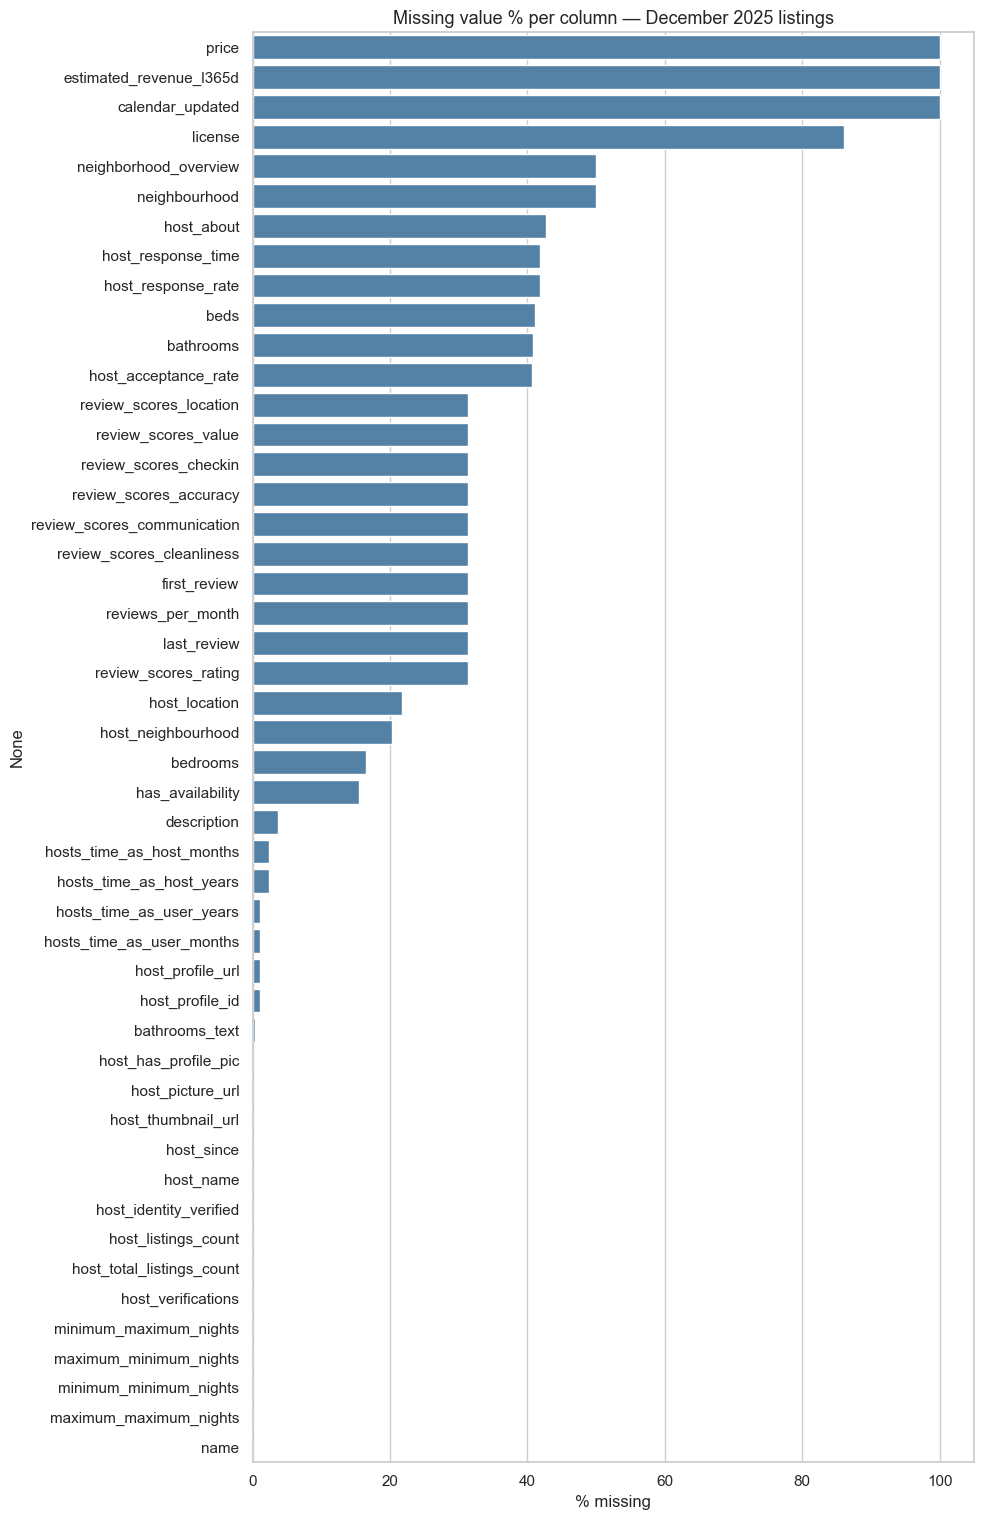

In [81]:
missing_pct = (listings.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print(f'{len(missing_pct)} columns have missing values')
print(missing_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(missing_pct))))
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color='steelblue')
ax.set_title('Missing value % per column — December 2025 listings')
ax.set_xlabel('% missing')
plt.tight_layout()
plt.savefig(OUT_DIR / 'missing_listings_dec2025.png', dpi=120)
plt.show()

### 4.2 Numerical Feature Distributions

In [82]:
# Price stored as "$150.00" — parse to float
listings['price_numeric'] = (
    listings['price'].astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .replace({'': np.nan, 'nan': np.nan})
    .astype(float)
)

# host_response_rate / host_acceptance_rate stored as "100%" or "N/A"
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in listings.columns:
        listings[col + '_num'] = (
            listings[col].astype(str)
            .str.replace('%', '', regex=False)
            .replace({'N/A': np.nan, 'nan': np.nan, '': np.nan})
            .astype(float)
        )

num_cols = [
    'price_numeric', 'accommodates', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month',
    'review_scores_rating', 'estimated_occupancy_l365d', 'estimated_revenue_l365d',
    'calculated_host_listings_count',
]
num_cols = [c for c in num_cols if c in listings.columns]
listings[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price_numeric,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,36261.0,2.75,1.88,1.00,2.00,2.00,4.00,1.600000e+01
bedrooms,30248.0,1.38,0.94,0.00,1.00,1.00,2.00,1.600000e+01
beds,21370.0,1.61,1.20,0.00,1.00,1.00,2.00,4.000000e+01
minimum_nights,36261.0,28.64,29.14,1.00,30.00,30.00,30.00,1.124000e+03
maximum_nights,36261.0,59784.33,11277422.83,1.00,130.00,365.00,1125.00,2.147484e+09
availability_30,36261.0,10.74,12.71,0.00,0.00,2.00,27.00,3.000000e+01
availability_60,36261.0,25.83,25.51,0.00,0.00,24.00,57.00,6.000000e+01
availability_90,36261.0,41.65,38.67,0.00,0.00,45.00,86.00,9.000000e+01
availability_365,36261.0,167.44,149.76,0.00,0.00,160.00,335.00,3.650000e+02


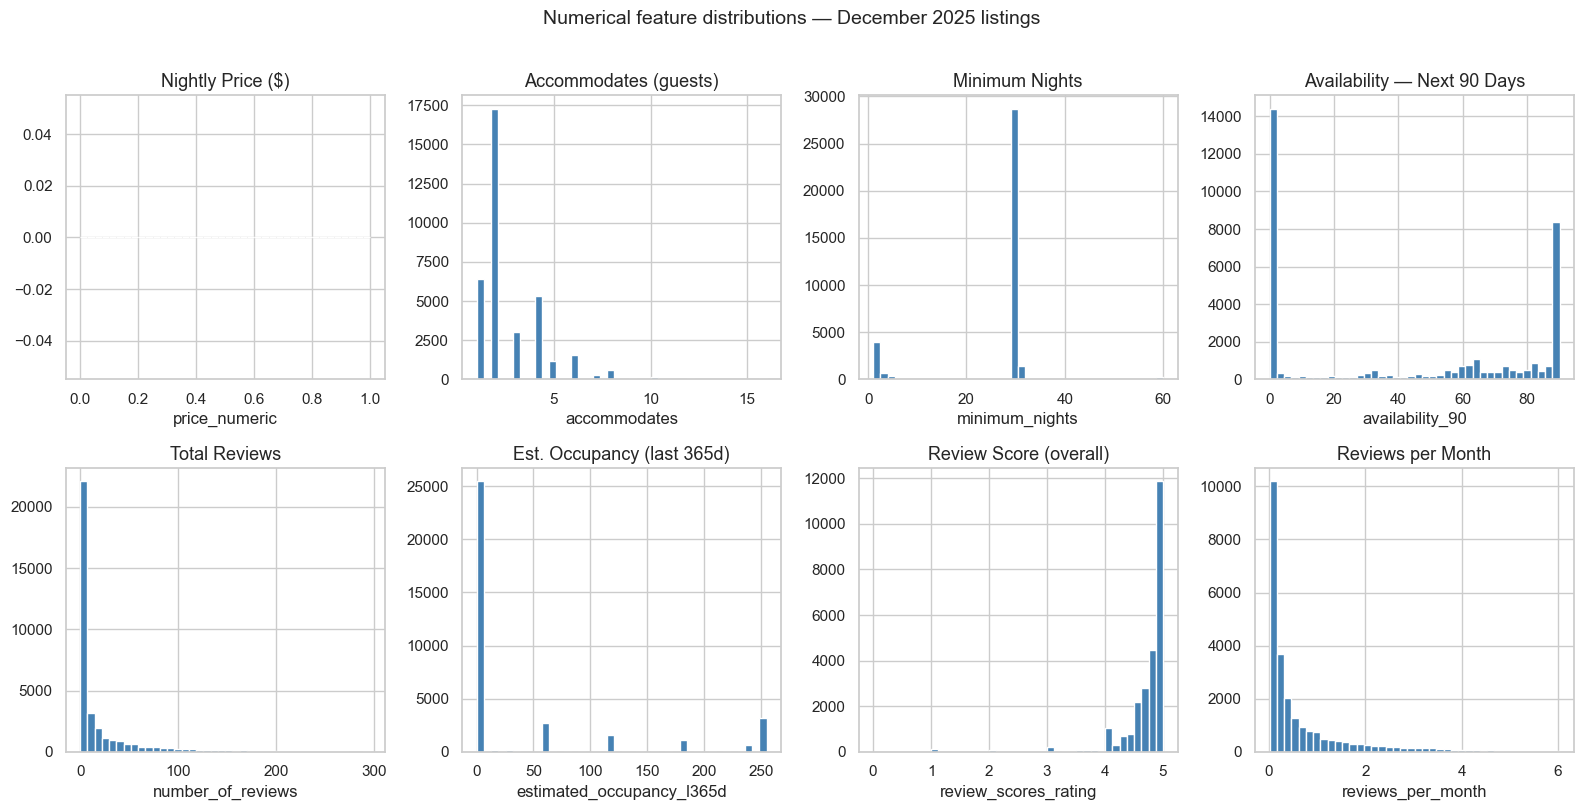

In [83]:
plot_specs = [
    ('price_numeric',             'Nightly Price ($)',               0.99),
    ('accommodates',              'Accommodates (guests)',           1.00),
    ('minimum_nights',            'Minimum Nights',                  0.98),
    ('availability_90',           'Availability — Next 90 Days',    1.00),
    ('number_of_reviews',         'Total Reviews',                   0.99),
    ('estimated_occupancy_l365d', 'Est. Occupancy (last 365d)',      1.00),
    ('review_scores_rating',      'Review Score (overall)',          1.00),
    ('reviews_per_month',         'Reviews per Month',               0.99),
]
plot_specs = [(c, lbl, q) for c, lbl, q in plot_specs if c in listings.columns]

n = len(plot_specs)
ncols_grid = 4
nrows_grid = (n + ncols_grid - 1) // ncols_grid
fig, axes = plt.subplots(nrows_grid, ncols_grid, figsize=(16, 4 * nrows_grid))
for ax, (col, label, q) in zip(axes.flat, plot_specs):
    data = listings[col].dropna()
    clip = data.quantile(q)
    ax.hist(data[data <= clip], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel(col)
for ax in axes.flat[n:]:
    ax.set_visible(False)
plt.suptitle('Numerical feature distributions — December 2025 listings', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / 'num_distributions_dec2025.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.3 Categorical Features

In [84]:
cat_cols = ['room_type', 'neighbourhood_group_cleansed', 'host_is_superhost',
            'instant_bookable', 'host_response_time', 'host_identity_verified']
cat_cols = [c for c in cat_cols if c in listings.columns]

for c in cat_cols:
    vc = listings[c].value_counts(dropna=False)
    print(f'{c} (unique={listings[c].nunique(dropna=False)}):')
    print(vc.head(8).to_string())
    print()

room_type (unique=4):
room_type
Entire home/apt    19452
Private room       16201
Hotel room           331
Shared room          277

neighbourhood_group_cleansed (unique=5):
neighbourhood_group_cleansed
Manhattan        16220
Brooklyn         13282
Queens            5256
Bronx             1139
Staten Island      364

host_is_superhost (unique=2):
host_is_superhost
f    29402
t     6859

instant_bookable (unique=2):
instant_bookable
f    28597
t     7664

host_response_time (unique=5):
host_response_time
NaN                   15173
within an hour        13772
within a few hours     3917
within a day           2160
a few days or more     1239

host_identity_verified (unique=3):
host_identity_verified
t      35432
f        818
NaN       11



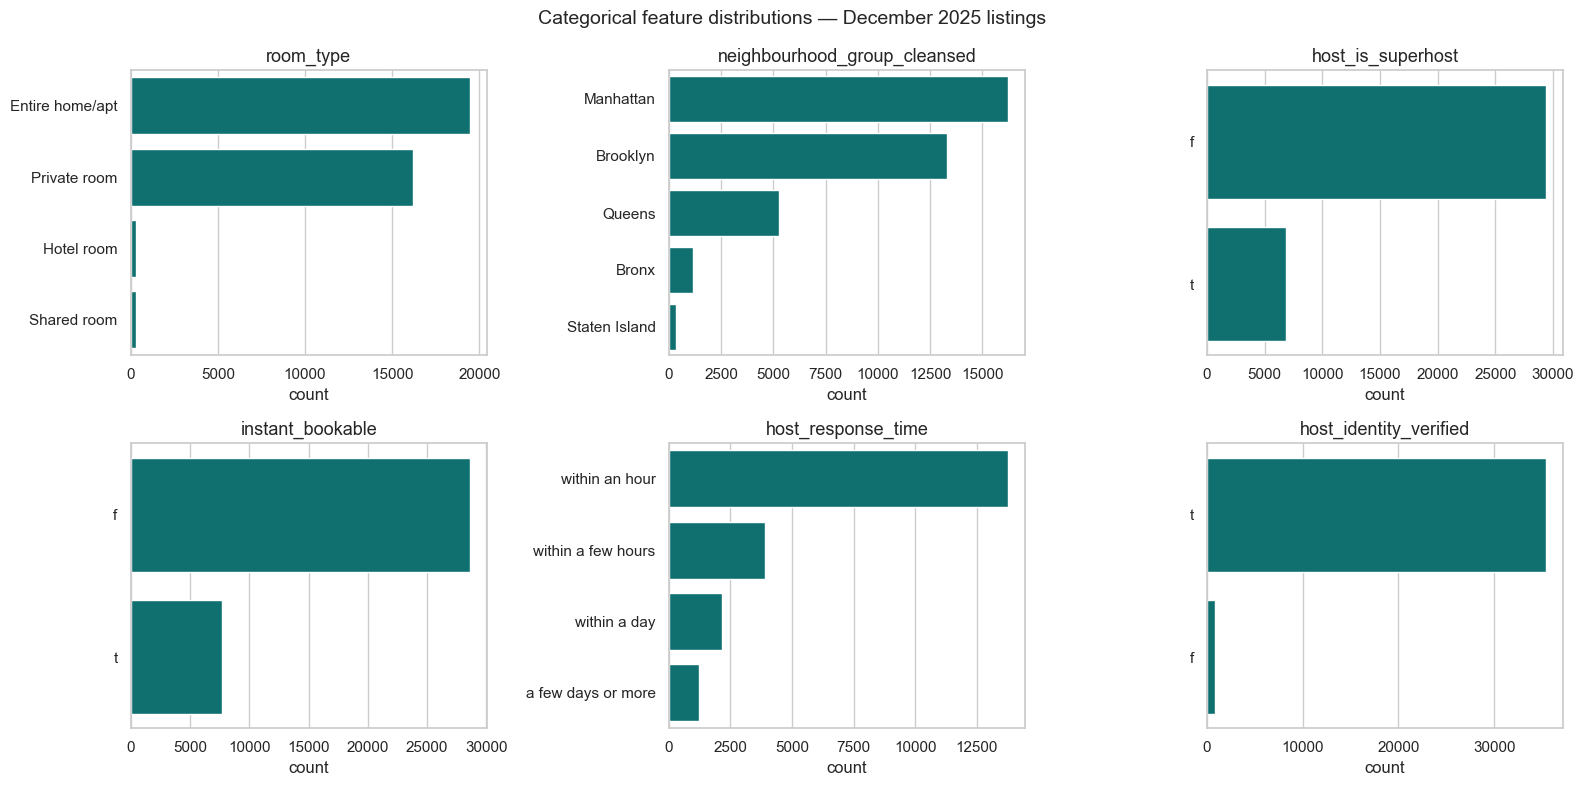

In [85]:
n_cats = len(cat_cols)
ncols_grid = 3
nrows_grid = (n_cats + ncols_grid - 1) // ncols_grid
fig, axes = plt.subplots(nrows_grid, ncols_grid, figsize=(16, 4 * nrows_grid))
for ax, col in zip(axes.flat, cat_cols):
    vc = listings[col].value_counts(dropna=False).head(10)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, color='teal')
    ax.set_title(col)
    ax.set_xlabel('count')
    ax.set_ylabel('')
for ax in axes.flat[n_cats:]:
    ax.set_visible(False)
plt.suptitle('Categorical feature distributions — December 2025 listings', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cat_distributions_dec2025.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.4 Date Features

                          count    mean     std   min     25%     50%     75%     max
host_age_days           36250.0  3175.1  1377.6  30.0  2203.2  3429.0  4182.0  6352.0
listing_age_days        24912.0  1983.4  1276.9  25.0   945.0  1687.0  3024.0  6065.0
days_since_last_review  24912.0  1057.1  1151.6  24.0    96.0   600.0  1995.2  5348.0


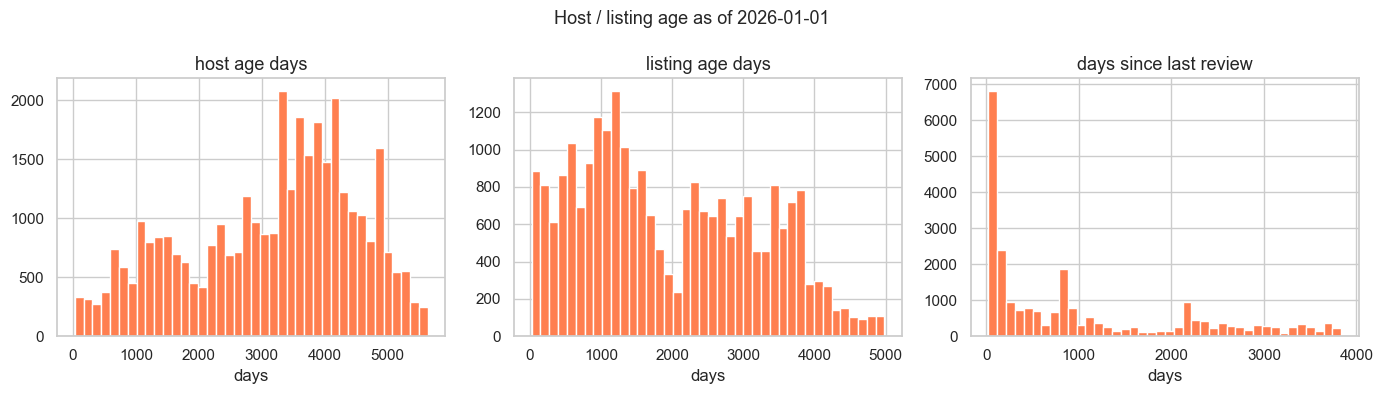

In [86]:
REF_DATE = pd.Timestamp('2026-01-01')  # start of prediction window

for col in ['host_since', 'first_review', 'last_review']:
    if col in listings.columns:
        listings[col] = pd.to_datetime(listings[col], errors='coerce')

if 'host_since' in listings.columns:
    listings['host_age_days'] = (REF_DATE - listings['host_since']).dt.days
if 'first_review' in listings.columns:
    listings['listing_age_days'] = (REF_DATE - listings['first_review']).dt.days
if 'last_review' in listings.columns:
    listings['days_since_last_review'] = (REF_DATE - listings['last_review']).dt.days

date_features = [c for c in ['host_age_days', 'listing_age_days', 'days_since_last_review']
                 if c in listings.columns]
print(listings[date_features].describe().round(1).T)

fig, axes = plt.subplots(1, len(date_features), figsize=(14, 4))
if len(date_features) == 1:
    axes = [axes]
for ax, col in zip(axes, date_features):
    data = listings[col].dropna()
    ax.hist(data[data <= data.quantile(0.99)], bins=40, color='coral', edgecolor='white')
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('days')
plt.suptitle('Host / listing age as of 2026-01-01', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'date_features_dec2025.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Target Variable — `blocked_days_Q1_2026`

We derive the target from calendar data covering **Jan 1 – Mar 31, 2026** (max 90 days: Jan=31,
Feb=28, Mar=31). This is the analogue of `NumReserveDays2016Q3` from the old Kaggle data.

**First pass (naive, single-snapshot):** count days in the **December 2025 calendar** where
`available = 'f'`. A blocked day is either booked by a guest or manually blocked by the host —
Inside Airbnb's `available ∈ {t,f}` cannot distinguish the two from a single snapshot; both read
as `'f'` for every future date, indistinguishably. Section 5.1 below audits how much this matters
before we commit to a target definition, the same way Section 11 audits price sources before
picking one.

In [87]:
print('Loading December 2025 calendar...')
dec_cal = pd.read_csv(
    DEC_DIR / 'calendar.csv',
    usecols=['listing_id', 'date', 'available'],
    dtype={'listing_id': 'int64', 'available': 'category'},
)
dec_cal['date'] = pd.to_datetime(dec_cal['date'])
print(f'Full calendar: {len(dec_cal):,} rows  |  dates: {dec_cal["date"].min().date()} → {dec_cal["date"].max().date()}')

# Filter to Q1 2026
q1_cal = dec_cal[(dec_cal['date'] >= '2026-01-01') & (dec_cal['date'] <= '2026-03-31')].copy()
print(f'Q1 2026 slice: {len(q1_cal):,} rows  |  {q1_cal["listing_id"].nunique():,} unique listings')

# Count blocked days per listing
target = (
    q1_cal
    .assign(is_blocked=(q1_cal['available'] == 'f').astype('int8'))
    .groupby('listing_id')
    .agg(
        blocked_days_Q1_2026=('is_blocked', 'sum'),
        days_in_q1_cal=('is_blocked', 'count'),
    )
    .reset_index()
    .rename(columns={'listing_id': 'id'})
)
target['id'] = target['id'].astype(str)

print('\nTarget shape:', target.shape)
target.head()

Loading December 2025 calendar...
Full calendar: 13,235,283 rows  |  dates: 2025-12-04 → 2026-12-10
Q1 2026 slice: 3,263,490 rows  |  36,261 unique listings

Target shape: (36261, 3)


,id,blocked_days_Q1_2026,days_in_q1_cal
0,2539,0,90
1,2595,0,90
2,6848,11,90
3,6872,28,90
4,6990,90,90


In [88]:
y = target['blocked_days_Q1_2026']
print(y.describe().round(2))
print(f'\nZero-blocked rate  : {(y == 0).mean():.3f}')
print(f'Fully-blocked rate : {(y == 90).mean():.3f}  (all 90 days blocked)')
print(f'Max possible days  : 90  (Jan=31, Feb=28, Mar=31)')

print('\nBlocking range breakdown:')
bins   = [0, 1, 15, 30, 45, 60, 75, 90, 91]
labels = ['0', '1–14', '15–29', '30–44', '45–59', '60–74', '75–89', '90']
cut = pd.cut(y, bins=bins, labels=labels, right=False)
print(cut.value_counts().sort_index().to_string())

count    36261.00
mean        44.22
std         41.12
min          0.00
25%          0.00
50%         31.00
75%         90.00
max         90.00
Name: blocked_days_Q1_2026, dtype: float64

Zero-blocked rate  : 0.325
Fully-blocked rate : 0.392  (all 90 days blocked)
Max possible days  : 90  (Jan=31, Feb=28, Mar=31)

Blocking range breakdown:
blocked_days_Q1_2026
0        11779
1–14      3563
15–29     2078
30–44     1684
45–59     1335
60–74      698
75–89      906
90       14218


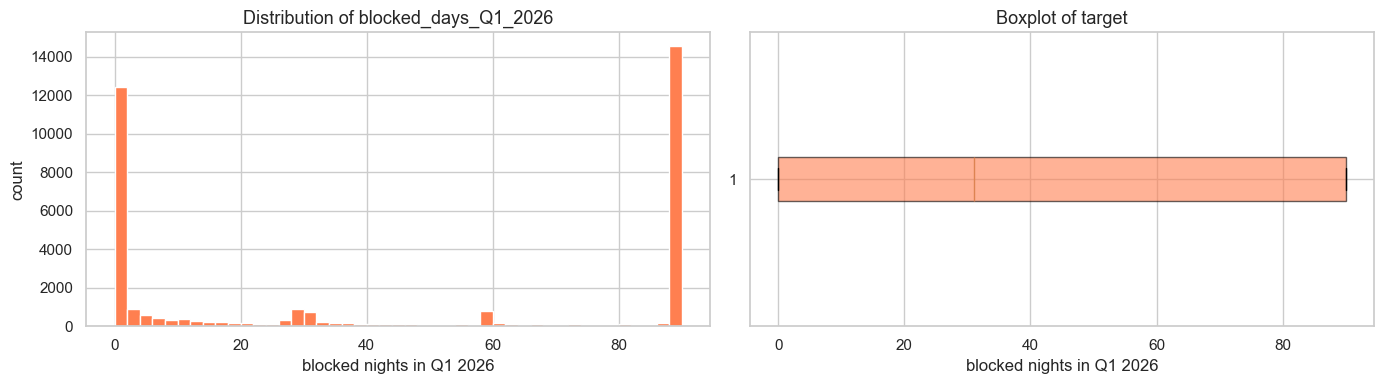

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y, bins=45, color='coral', edgecolor='white')
axes[0].set_title('Distribution of blocked_days_Q1_2026')
axes[0].set_xlabel('blocked nights in Q1 2026')
axes[0].set_ylabel('count')

axes[1].boxplot(y, vert=False, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.6))
axes[1].set_title('Boxplot of target')
axes[1].set_xlabel('blocked nights in Q1 2026')

plt.tight_layout()
plt.savefig(OUT_DIR / 'target_distribution.png', dpi=120)
plt.show()

### 5.1 Does the single-snapshot conflation actually matter?

December's calendar is *one* observation of each Q1-2026 date, taken 1–3 months ahead of time.
January's calendar re-observes the **same dates**, 0–2 months ahead. If a date reads `'f'` in
December because it is a real, held booking, it should still read `'f'` in January. If instead
it reads `'f'` merely because the host pre-blocks far in advance (minimum-stay placeholders,
manual calendar closes that get revised, etc.), January may show it `'t'` again. Comparing the
two snapshots on the same dates quantifies how often that happens.

In [90]:
print('Loading January 2026 calendar (second, closer-in snapshot of the same Q1 2026 dates)...')
jan_cal = pd.read_csv(
    Q1_DIR / 'January2026' / 'calendar.csv',
    usecols=['listing_id', 'date', 'available'],
    dtype={'listing_id': 'int64', 'available': 'category'},
)
jan_cal['date'] = pd.to_datetime(jan_cal['date'])
jan_cal = jan_cal[(jan_cal['date'] >= '2026-01-01') & (jan_cal['date'] <= '2026-03-31')]
print(f'January-scrape view of Q1 2026: {len(jan_cal):,} rows | {jan_cal["listing_id"].nunique():,} listings')

# Compare, per (listing, date), what December's snapshot said vs. what January's said
# about the SAME calendar date -- two independent observations of the same future day.
dec_view = dec_cal.rename(columns={'available': 'av_dec'})[['listing_id', 'date', 'av_dec']]
jan_view = jan_cal.rename(columns={'available': 'av_jan'})[['listing_id', 'date', 'av_jan']]
compare = dec_view.merge(jan_view, on=['listing_id', 'date'], how='inner')
print(f'\nDates observed by BOTH snapshots: {len(compare):,}')

agree_blocked = ((compare['av_dec'] == 'f') & (compare['av_jan'] == 'f')).mean()
agree_open    = ((compare['av_dec'] == 't') & (compare['av_jan'] == 't')).mean()
newly_booked  = ((compare['av_dec'] == 't') & (compare['av_jan'] == 'f')).mean()  # unambiguous new booking
reopened      = ((compare['av_dec'] == 'f') & (compare['av_jan'] == 't')).mean()  # Dec 'blocked' wasn't firm

print(f"agree blocked (f→f) : {agree_blocked:.1%}   <- ambiguous: could be a held booking OR a dead/host-blocked listing")
print(f"agree open (t→t)    : {agree_open:.1%}")
print(f"newly booked (t→f)  : {newly_booked:.1%}   <- unambiguous demand signal")
print(f"reopened (f→t)      : {reopened:.1%}   <- December's 'blocked' reading was NOT a firm booking")

flip_rate = reopened / (agree_blocked + reopened)
print(f'\n{flip_rate:.1%} of date-observations that December read as blocked flip back to available by '
      f'January. A naive single-snapshot count has no way to separate these from real bookings, which '
      f'is exactly the host-block/demand conflation this project corrects for: `blocked_days_Q1_2026` '
      f'in `02_FeatureEngineering.ipynb` (Section 6) instead uses a clean multi-snapshot rule -- a date '
      f'only counts as booked if it was ever seen available AND its last-observed state is unavailable '
      f'AND it was observed in >=2 of the six Oct2025-Mar2026 snapshots, so a transition like the '
      f'"reopened" case above is correctly excluded rather than counted as demand.')

Loading January 2026 calendar (second, closer-in snapshot of the same Q1 2026 dates)...
January-scrape view of Q1 2026: 2,743,685 rows | 36,286 listings

Dates observed by BOTH snapshots: 2,660,485
agree blocked (f→f) : 46.0%   <- ambiguous: could be a held booking OR a dead/host-blocked listing
agree open (t→t)    : 42.7%
newly booked (t→f)  : 8.0%   <- unambiguous demand signal
reopened (f→t)      : 3.2%   <- December's 'blocked' reading was NOT a firm booking

6.6% of date-observations that December read as blocked flip back to available by January. A naive single-snapshot count has no way to separate these from real bookings, which is exactly the host-block/demand conflation this project corrects for: `blocked_days_Q1_2026` in `02_FeatureEngineering.ipynb` (Section 6) instead uses a clean multi-snapshot rule -- a date only counts as booked if it was ever seen available AND its last-observed state is unavailable AND it was observed in >=2 of the six Oct2025-Mar2026 snapshots, so a t

## 6. Calendar Data Exploration

Each monthly scrape's `calendar.csv` covers ~365 days forward from the scrape date.  
For training features we use **each month's scrape filtered to that month's own dates**, giving a continuous
6-month availability record for Q3+Q4 2025:

| Scrape | Filter window | Note |
|---|---|---|
| July 2025 | Jul 1–31 | |
| August 2025 | Aug 2–31 | scrape starts Aug 2 |
| September 2025 | Sep 2–30 | scrape starts Sep 2 |
| October 2025 | Oct 1–31 | |
| November 2025 | Nov 2–30 | scrape starts Nov 2 |
| December 2025 | Dec 4–31 | scrape starts Dec 4 |

In [91]:
# Load October 2025 calendar (representative Q4 month) filtered to Oct dates
print('Loading October 2025 calendar (Oct dates only)...')
oct_cal = pd.read_csv(
    Q4_DIR / 'October2025' / 'calendar.csv',
    usecols=['listing_id', 'date', 'available', 'price'],
    dtype={'listing_id': 'int64', 'available': 'category'},
)
oct_cal['date'] = pd.to_datetime(oct_cal['date'])
oct_cal = oct_cal[(oct_cal['date'] >= '2025-10-01') & (oct_cal['date'] <= '2025-10-31')]
print(f'Rows: {len(oct_cal):,}  |  Listings: {oct_cal["listing_id"].nunique():,}')

avail_vc = oct_cal['available'].value_counts()
total = len(oct_cal)
print(f'\navailable=t (open)  : {avail_vc.get("t", 0):>8,}  ({avail_vc.get("t", 0)/total:.1%})')
print(f'available=f (blocked): {avail_vc.get("f", 0):>8,}  ({avail_vc.get("f", 0)/total:.1%})')

Loading October 2025 calendar (Oct dates only)...
Rows: 1,085,967  |  Listings: 36,111

available=t (open)  :  316,126  (29.1%)
available=f (blocked):  769,841  (70.9%)


Month       Rows    Block rate
Jul    1,093,964         0.702
Aug    1,080,922         0.660
Sep    1,047,224         0.708
Oct    1,085,967         0.709
Nov    1,045,723         0.670
Dec      982,765         0.649


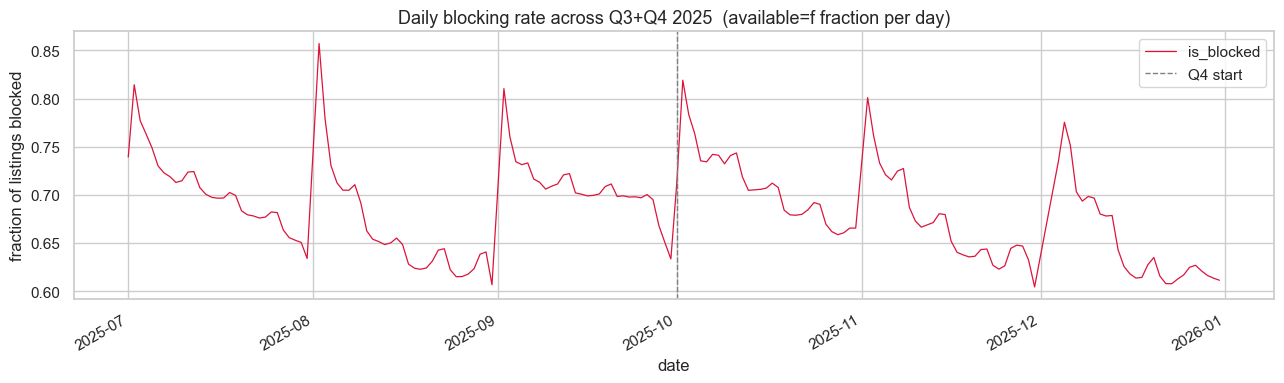

In [92]:
# Seasonal daily blocking rate across all 6 months of Q3+Q4 2025
month_configs = [
    ('Jul', Q3_DIR / 'July2025'      / 'calendar.csv', '2025-07-01', '2025-07-31'),
    ('Aug', Q3_DIR / 'August2025'    / 'calendar.csv', '2025-08-02', '2025-08-31'),
    ('Sep', Q3_DIR / 'September2025' / 'calendar.csv', '2025-09-02', '2025-09-30'),
    ('Oct', Q4_DIR / 'October2025'   / 'calendar.csv', '2025-10-01', '2025-10-31'),
    ('Nov', Q4_DIR / 'November2025'  / 'calendar.csv', '2025-11-02', '2025-11-30'),
    ('Dec', Q4_DIR / 'December2025'  / 'calendar.csv', '2025-12-04', '2025-12-31'),
]

daily_parts = []
print(f'{"Month":<5} {"Rows":>10}  {"Block rate":>12}')
for label, path, start, end in month_configs:
    cal = pd.read_csv(path, usecols=['listing_id', 'date', 'available'],
                      dtype={'available': 'category'})
    cal['date'] = pd.to_datetime(cal['date'])
    cal = cal[(cal['date'] >= start) & (cal['date'] <= end)]
    cal['is_blocked'] = (cal['available'] == 'f').astype('int8')
    daily = cal.groupby('date')['is_blocked'].mean()
    daily_parts.append(daily)
    print(f'{label:<5} {len(cal):>10,}  {cal["is_blocked"].mean():>12.3f}')

daily_trend = pd.concat(daily_parts).sort_index()

fig, ax = plt.subplots(figsize=(13, 4))
daily_trend.plot(ax=ax, color='crimson', linewidth=0.9)
ax.axvline(pd.Timestamp('2025-10-01'), color='gray', linestyle='--', linewidth=1, label='Q4 start')
ax.set_title('Daily blocking rate across Q3+Q4 2025  (available=f fraction per day)')
ax.set_ylabel('fraction of listings blocked')
ax.set_xlabel('date')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'daily_blocking_rate_H2_2025.png', dpi=120)
plt.show()

Rows with empty price: 100.0%  (calendar price is often absent)


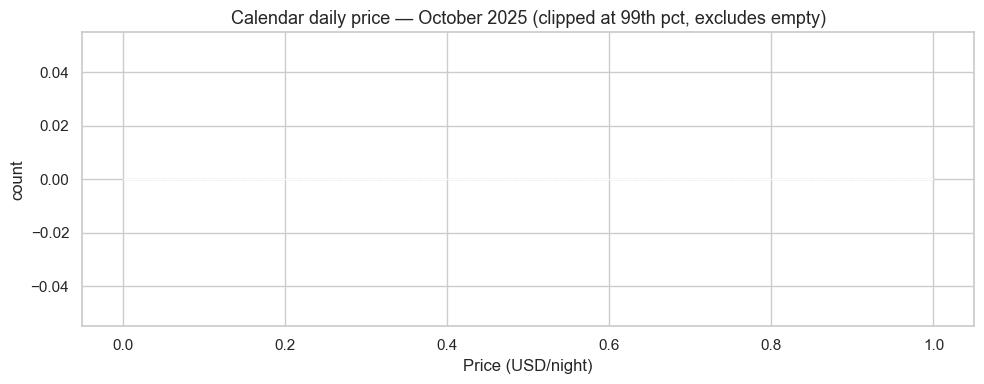


Oct 2025 calendar price — Mean: $nan | Median: $nan | P25: $nan | P75: $nan


In [93]:
# Price distribution in calendar (October 2025 sample)
oct_prices = (
    oct_cal['price'].astype(str)
    .str.replace(r'[\$,]', '', regex=True)
)
oct_prices = pd.to_numeric(oct_prices, errors='coerce').dropna()
oct_prices = oct_prices[(oct_prices > 0) & (oct_prices < oct_prices.quantile(0.99))]

empty_frac = (oct_cal['price'].isna() | (oct_cal['price'].astype(str) == '')).mean()
print(f'Rows with empty price: {empty_frac:.1%}  (calendar price is often absent)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(oct_prices, bins=60, color='steelblue', edgecolor='white')
ax.set_title('Calendar daily price — October 2025 (clipped at 99th pct, excludes empty)')
ax.set_xlabel('Price (USD/night)')
ax.set_ylabel('count')
plt.tight_layout()
plt.savefig(OUT_DIR / 'calendar_price_oct2025.png', dpi=120)
plt.show()

print(f'\nOct 2025 calendar price — Mean: ${oct_prices.mean():.0f} | '
      f'Median: ${oct_prices.median():.0f} | '
      f'P25: ${oct_prices.quantile(0.25):.0f} | '
      f'P75: ${oct_prices.quantile(0.75):.0f}')

## 7. Merged Feature Set & Correlations with Target

Merge the December 2025 listing metadata with the derived Q1 2026 target to see which listing-level
attributes correlate with the number of blocked days. This uses only the listing metadata, not the
calendar aggregates — those come in `02_FeatureEngineering.ipynb`.

In [94]:
listings['id'] = listings['id'].astype(str)
train_df = target.merge(listings, on='id', how='inner')
print(f'Merged shape        : {train_df.shape}')
print(f'Listings with target: {len(target):,}')
print(f'Listings with meta  : {len(listings):,}')
print(f'Inner join result   : {len(train_df):,}  (listings present in both)')

Merged shape        : (36261, 93)
Listings with target: 36,261
Listings with meta  : 36,261
Inner join result   : 36,261  (listings present in both)


In [95]:
# Encode t/f boolean flags
bool_map = {'t': 1, 'f': 0}
for col in ['host_is_superhost', 'instant_bookable', 'host_identity_verified', 'host_has_profile_pic']:
    if col in train_df.columns:
        train_df[col + '_enc'] = train_df[col].map(bool_map)

drop_cols = ['id', 'host_id', 'days_in_q1_cal', 'scrape_id',
             'calculated_host_listings_count_entire_homes',
             'calculated_host_listings_count_private_rooms',
             'calculated_host_listings_count_shared_rooms']

num_train = train_df.select_dtypes(include='number').drop(columns=drop_cols, errors='ignore')

corr_target = (
    num_train.corr(numeric_only=True)['blocked_days_Q1_2026']
    .drop('blocked_days_Q1_2026', errors='ignore')
    .sort_values(key=abs, ascending=False)
)
print('Top 25 listing metadata features by |correlation| with target:')
print(corr_target.head(25).round(4).to_string())

Top 25 listing metadata features by |correlation| with target:
availability_90             -0.9594
availability_60             -0.8981
availability_365            -0.8583
availability_30             -0.7361
availability_eoy            -0.7139
days_since_last_review       0.5510
listing_age_days             0.3467
hosts_time_as_host_years     0.2930
host_age_days                0.2867
hosts_time_as_user_years     0.2804
estimated_occupancy_l365d   -0.2364
reviews_per_month           -0.2083
host_is_superhost_enc       -0.1877
number_of_reviews_ltm       -0.1288
number_of_reviews_l30d      -0.1222
instant_bookable_enc        -0.1207
number_of_reviews           -0.1167
host_profile_id             -0.1131
review_scores_value          0.1123
number_of_reviews_ly        -0.1073
host_acceptance_rate_num     0.1056
host_response_rate_num       0.0929
longitude                   -0.0894
host_has_profile_pic_enc     0.0824
review_scores_accuracy       0.0820


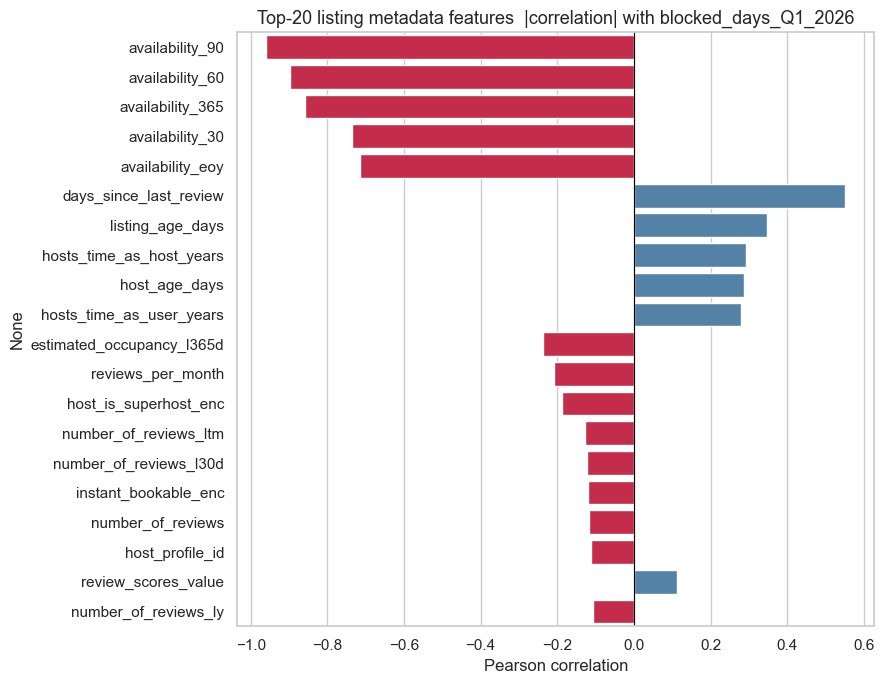

In [96]:
top20 = corr_target.head(20)
colors = ['crimson' if v < 0 else 'steelblue' for v in top20.values]

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=top20.values, y=top20.index, ax=ax, palette=colors)
ax.set_title('Top-20 listing metadata features  |correlation| with blocked_days_Q1_2026')
ax.set_xlabel('Pearson correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'top_correlations.png', dpi=120)
plt.show()

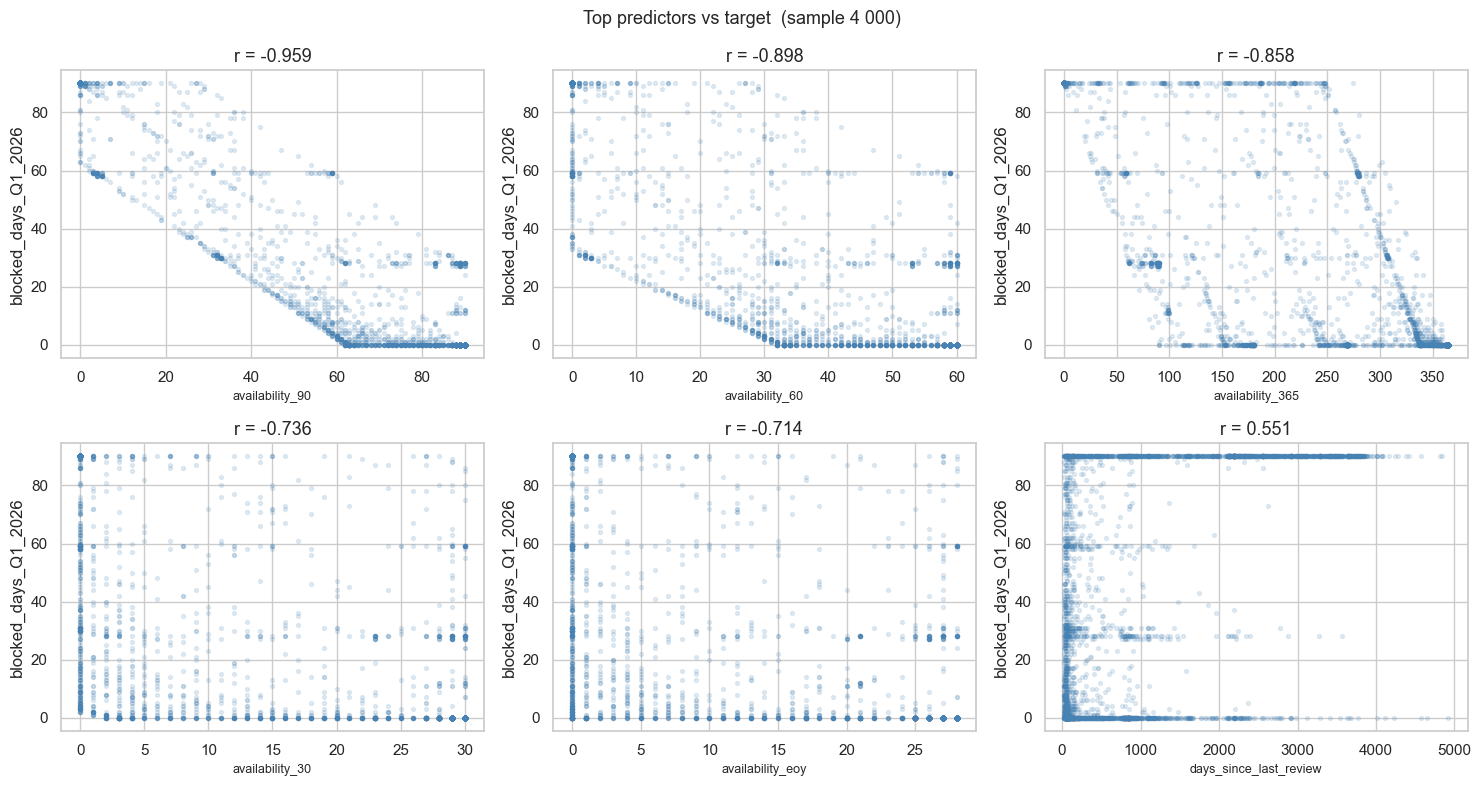

In [97]:
scatter_cols = [c for c in corr_target.head(6).index if c in train_df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, scatter_cols):
    sub = train_df[[col, 'blocked_days_Q1_2026']].dropna()
    sub = sub.sample(min(4000, len(sub)), random_state=RANDOM_STATE)
    ax.scatter(sub[col], sub['blocked_days_Q1_2026'], alpha=0.15, s=8, color='steelblue')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('blocked_days_Q1_2026')
    ax.set_title(f'r = {corr_target.get(col, float("nan")):.3f}')
for ax in axes.flat[len(scatter_cols):]:
    ax.set_visible(False)
plt.suptitle('Top predictors vs target  (sample 4 000)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'scatter_top_predictors.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Categorical & Geographic Analysis

In [98]:
for col in ['room_type', 'neighbourhood_group_cleansed', 'host_is_superhost', 'instant_bookable']:
    if col in train_df.columns:
        grp = (
            train_df.groupby(col)['blocked_days_Q1_2026']
            .agg(['mean', 'median', 'count'])
            .round(2)
            .sort_values('mean', ascending=False)
        )
        print(f'\n--- {col} ---')
        print(grp.to_string())


--- room_type ---
                  mean  median  count
room_type                            
Entire home/apt  45.29    37.0  19452
Private room     43.82    31.0  16201
Shared room      28.86     1.0    277
Hotel room       13.79     2.0    331

--- neighbourhood_group_cleansed ---
                               mean  median  count
neighbourhood_group_cleansed                      
Brooklyn                      46.34    41.0  13282
Manhattan                     45.59    38.0  16220
Queens                        39.45    28.0   5256
Bronx                         29.54     1.0   1139
Staten Island                 20.63     0.0    364

--- host_is_superhost ---
                    mean  median  count
host_is_superhost                      
f                  47.95    59.0  29402
t                  28.24    10.0   6859

--- instant_bookable ---
                   mean  median  count
instant_bookable                      
f                 46.79    46.0  28597
t                 34.63    1

In [99]:
if 'neighbourhood_cleansed' in train_df.columns:
    nb = (
        train_df.groupby('neighbourhood_cleansed')['blocked_days_Q1_2026']
        .agg(['mean', 'count'])
        .query('count >= 50')
        .sort_values('mean', ascending=False)
    )
    print('Top 15 neighbourhoods (≥50 listings) by avg blocked nights:')
    print(nb.head(15).round(2).to_string())
    print('\nBottom 15:')
    print(nb.tail(15).round(2).to_string())

Top 15 neighbourhoods (≥50 listings) by avg blocked nights:
                         mean  count
neighbourhood_cleansed              
Inwood                  67.29    161
Morningside Heights     66.54    190
Brooklyn Heights        65.81     75
Elmhurst                64.88    287
Woodside                63.72    298
Prospect Heights        62.19    179
East Village            60.81    954
Greenwich Village       60.79    214
Williamsburg            59.36   2056
South Slope             59.20    168
Battery Park City       58.97     69
Carroll Gardens         57.78    141
Kingsbridge             57.35     62
Greenpoint              56.63    600
West Village            56.61    473

Bottom 15:
                         mean  count
neighbourhood_cleansed              
Cambria Heights         26.24     59
Ozone Park              26.22     90
Richmond Hill           26.12     94
Wakefield               25.79     68
Theater District        25.52    347
Cypress Hills           25.05    168
Col

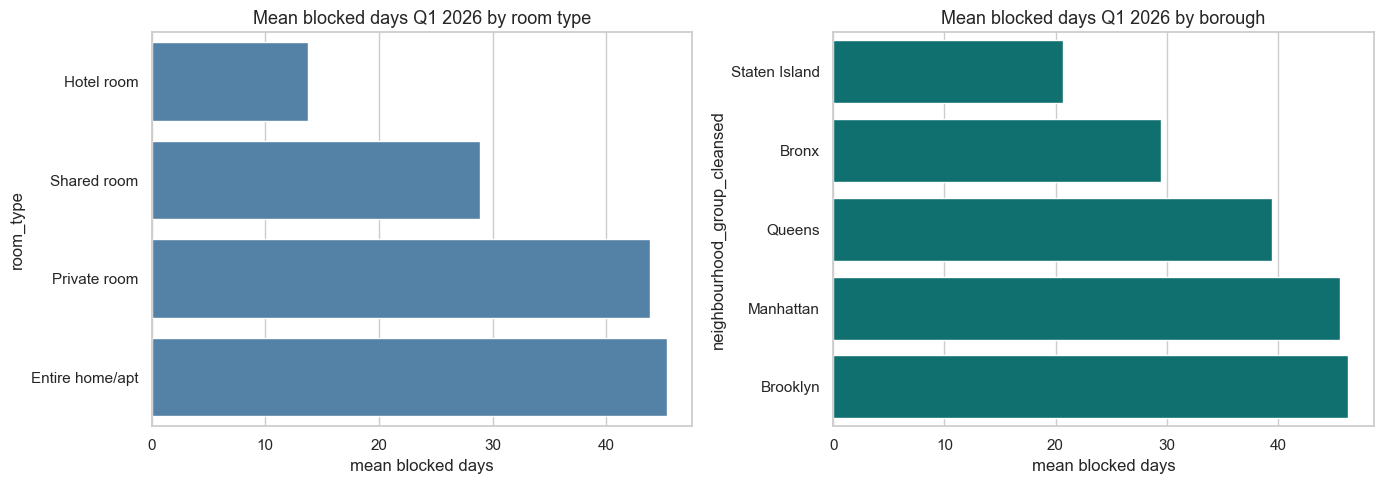

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'room_type' in train_df.columns:
    rt = train_df.groupby('room_type')['blocked_days_Q1_2026'].mean().sort_values()
    sns.barplot(x=rt.values, y=rt.index, ax=axes[0], color='steelblue')
    axes[0].set_title('Mean blocked days Q1 2026 by room type')
    axes[0].set_xlabel('mean blocked days')

if 'neighbourhood_group_cleansed' in train_df.columns:
    bor = train_df.groupby('neighbourhood_group_cleansed')['blocked_days_Q1_2026'].mean().sort_values()
    sns.barplot(x=bor.values, y=bor.index, ax=axes[1], color='teal')
    axes[1].set_title('Mean blocked days Q1 2026 by borough')
    axes[1].set_xlabel('mean blocked days')

plt.tight_layout()
plt.savefig(OUT_DIR / 'cat_target_analysis.png', dpi=120)
plt.show()

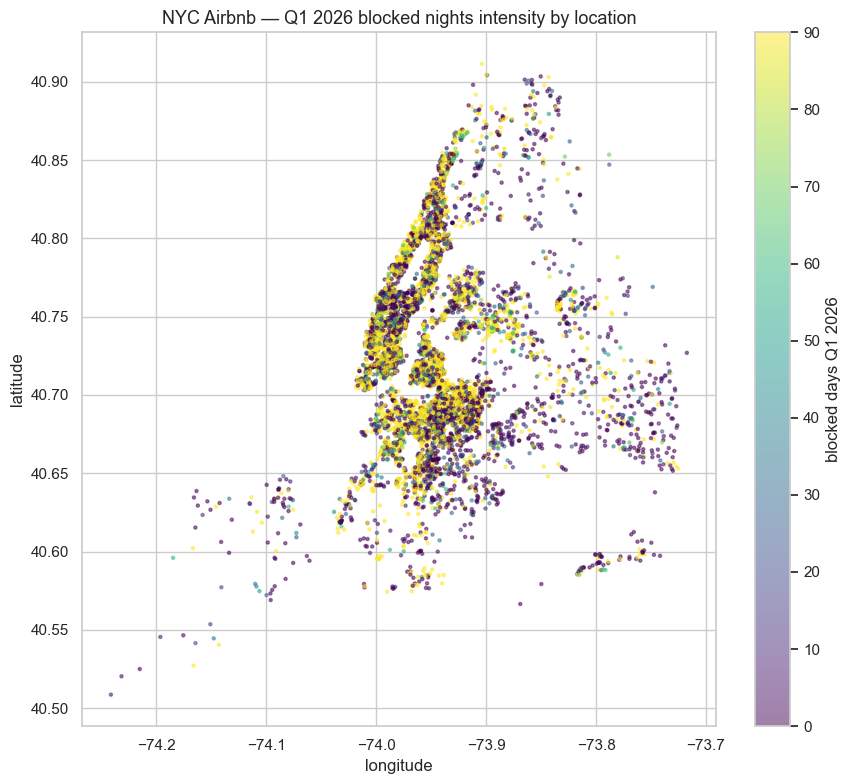

In [101]:
geo = train_df[['latitude', 'longitude', 'blocked_days_Q1_2026']].dropna()
geo = geo[
    geo['latitude'].between(40.4, 41.0) &
    geo['longitude'].between(-74.3, -73.6)
]
sample = geo.sample(min(8000, len(geo)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(
    sample['longitude'], sample['latitude'],
    c=sample['blocked_days_Q1_2026'],
    cmap='viridis', s=5, alpha=0.5
)
plt.colorbar(sc, ax=ax, label='blocked days Q1 2026')
ax.set_title('NYC Airbnb — Q1 2026 blocked nights intensity by location')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.tight_layout()
plt.savefig(OUT_DIR / 'geo_blocked_days.png', dpi=120)
plt.show()

## 10. Listing Coverage Across All 6 Months

Inside Airbnb scrapes NYC every 1–2 months. Some listings appear in all scrapes;
others are new or have been delisted. We need to know the overlap to plan how to
handle missing calendar features in the feature-engineering step.

In [102]:
import os

month_dirs = [
    ('Jul-25', Q3_DIR / 'July2025'),
    ('Aug-25', Q3_DIR / 'August2025'),
    ('Sep-25', Q3_DIR / 'September2025'),
    ('Oct-25', Q4_DIR / 'October2025'),
    ('Nov-25', Q4_DIR / 'November2025'),
    ('Dec-25', Q4_DIR / 'December2025'),
]

id_sets = {}
for label, d in month_dirs:
    p = detailed_listings_path(d)
    ids = set(pd.read_csv(p, usecols=['id'], dtype=str)['id'])
    id_sets[label] = ids
    print(f'{label}: {len(ids):,} listings')

in_all_6  = set.intersection(*id_sets.values())
in_any_1  = set.union(*id_sets.values())
target_ids = set(target['id'])

print(f'\nIn ALL 6 months : {len(in_all_6):,}')
print(f'In at least 1   : {len(in_any_1):,}')
print(f'Missing ≥1 month: {len(in_any_1) - len(in_all_6):,}')
print(f'\nTarget listings (Dec calendar): {len(target_ids):,}')
print(f'Target in all 6 months        : {len(target_ids & in_all_6):,}')
print(f'Target missing ≥1 month       : {len(target_ids - in_all_6):,}')
print()
print('Decision: keep all listings in target (Dec calendar).',
      'Calendar features will be NaN for months where a listing is absent —',
      'XGBoost and imputed pipelines handle this naturally.')

Jul-25: 36,345 listings
Aug-25: 36,403 listings
Sep-25: 36,178 listings
Oct-25: 36,111 listings
Nov-25: 36,353 listings
Dec-25: 36,261 listings

In ALL 6 months : 32,582
In at least 1   : 40,479
Missing ≥1 month: 7,897

Target listings (Dec calendar): 36,261
Target in all 6 months        : 32,582
Target missing ≥1 month       : 3,679

Decision: keep all listings in target (Dec calendar). Calendar features will be NaN for months where a listing is absent — XGBoost and imputed pipelines handle this naturally.


## 11. Price Coverage — Source Decision

The `price` column (nightly rate) in the **December 2025** detailed listings is **100% empty** —
a known data quality issue for that scrape. We audit every month to pick the best price source.

In [103]:
price_audit = []
price_id_sets = {}
for label, d in month_dirs:
    p = detailed_listings_path(d)
    df_tmp = pd.read_csv(p, usecols=['id', 'price',
                                       'estimated_revenue_l365d',
                                       'estimated_occupancy_l365d'],
                          dtype=str, low_memory=False)
    n = len(df_tmp)
    has_price = df_tmp['price'].notna() & (df_tmp['price'].str.strip() != '')
    empty_p = (~has_price).sum()
    empty_r = (df_tmp['estimated_revenue_l365d'].isna() |
               (df_tmp['estimated_revenue_l365d'].str.strip() == '')).sum()
    price_audit.append({'month': label, 'total': n,
                        'empty_price': empty_p, 'pct_empty': empty_p/n,
                        'empty_revenue': empty_r})
    price_id_sets[label] = set(df_tmp.loc[has_price, 'id'])

audit_df = pd.DataFrame(price_audit)
audit_df['pct_has_price'] = (1 - audit_df['pct_empty']).round(3)
print(audit_df[['month','total','empty_price','pct_empty','pct_has_price']].to_string(index=False))

# Does a single month leave real coverage on the table, or do the same listings just
# repeat their price (or lack of it) every month? Check the actual union vs. best-single-month.
five_months = ['Jul-25', 'Aug-25', 'Sep-25', 'Oct-25', 'Nov-25']
best_single = max(len(price_id_sets[m]) for m in five_months)
union_5mo   = set.union(*[price_id_sets[m] for m in five_months])
target_universe = len(listings)  # December 2025 listing count, the target universe

print(f'\nBest single month (has-price ids)  : {best_single:,}  ({best_single/target_universe:.1%} of Dec universe)')
print(f'Union across Jul-Nov (has-price any): {len(union_5mo):,}  ({len(union_5mo)/target_universe:.1%} of Dec universe)')
print(f'Extra listings recovered by 5-month union vs best single month: {len(union_5mo) - best_single:,}')

print('\n>> December 2025: 100% empty — DO NOT use for price.')
print('>> Each Jul-Nov month is missing a partly different set of listings (see union check above),')
print('>> so averaging price across all 5 months that report it recovers more coverage than any single')
print('>> month, plus gives trend/volatility features -- see 02_FeatureEngineering.ipynb Section 4.')
print('>> Remaining gaps: estimated_revenue_l365d / estimated_occupancy_l365d implied rate, then a')
print('>> neighbourhood-relative price (stays defined with no raw price at all), then an explicit')
print('>> price_missing flag so non-disclosure itself is usable as a signal.')

 month  total  empty_price  pct_empty  pct_has_price
Jul-25  36345        15021   0.413289          0.587
Aug-25  36403        15124   0.415460          0.585
Sep-25  36178        15037   0.415639          0.584
Oct-25  36111        14783   0.409377          0.591
Nov-25  36353        14938   0.410915          0.589
Dec-25  36261        36261   1.000000          0.000

Best single month (has-price ids)  : 21,415  (59.1% of Dec universe)
Union across Jul-Nov (has-price any): 26,731  (73.7% of Dec universe)
Extra listings recovered by 5-month union vs best single month: 5,316

>> December 2025: 100% empty — DO NOT use for price.
>> Each Jul-Nov month is missing a partly different set of listings (see union check above),
>> so averaging price across all 5 months that report it recovers more coverage than any single
>> month, plus gives trend/volatility features -- see 02_FeatureEngineering.ipynb Section 4.
>> Remaining gaps: estimated_revenue_l365d / estimated_occupancy_l365d implied rate

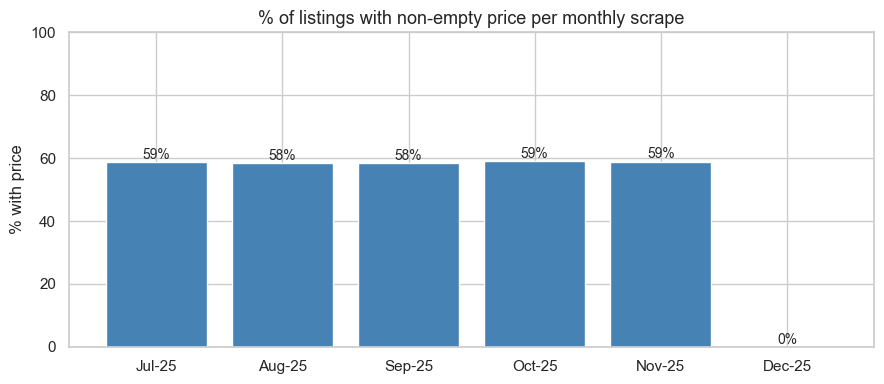

In [104]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(audit_df['month'], audit_df['pct_has_price'] * 100, color='steelblue', edgecolor='white')
ax.set_title('% of listings with non-empty price per monthly scrape')
ax.set_ylabel('% with price')
ax.set_ylim(0, 100)
for i, row in audit_df.iterrows():
    ax.text(i, row['pct_has_price'] * 100 + 1, f"{row['pct_has_price']*100:.0f}%",
            ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'price_coverage_by_month.png', dpi=120)
plt.show()

## 12. Property Type Taxonomy — New Schema

Inside Airbnb uses a combined `property_type` field (e.g., `'Entire rental unit'`) instead of
the old Kaggle split of `PropertyType` (Apartment/House) and `ListingType` (Entire/Private/Shared).
We map it to 5 compact groups for encoding.

In [105]:
pt = listings['property_type'].value_counts(dropna=False)
print('Top 20 property_type values:')
print(pt.head(20).to_string())

# Compact mapping for feature engineering
def map_property_type(pt_str):
    if pd.isna(pt_str): return 'Other'
    s = str(pt_str).lower()
    if 'hotel' in s or 'hostel' in s or 'boutique' in s: return 'Hotel/Hostel'
    if s.startswith('entire'): return 'Entire Place'
    if 'private room' in s: return 'Private Room'
    if 'shared room' in s or 'shared' in s: return 'Shared Room'
    return 'Other'

listings['property_type_grp'] = listings['property_type'].apply(map_property_type)
grp_counts = listings['property_type_grp'].value_counts()
print('\nGrouped property_type_grp:')
print(grp_counts.to_string())

if 'property_type_grp' in train_df.columns or True:
    tmp = listings[['id', 'property_type_grp']].merge(
        train_df[['id', 'blocked_days_Q1_2026']], on='id', how='inner')
    grp_target = tmp.groupby('property_type_grp')['blocked_days_Q1_2026'].mean().sort_values(ascending=False)
    print('\nMean blocked days Q1 2026 by property type group:')
    print(grp_target.round(2).to_string())

Top 20 property_type values:
property_type
Entire rental unit                    15462
Private room in rental unit            9641
Private room in home                   2661
Room in hotel                          1550
Entire home                            1279
Private room in townhouse              1080
Entire condo                           1078
Private room in condo                   477
Entire loft                             475
Entire townhouse                        466
Entire guest suite                      288
Room in boutique hotel                  235
Shared room in rental unit              214
Private room in serviced apartment      214
Private room in loft                    192
Private room in guest suite             153
Entire serviced apartment               147
Private room in bed and breakfast        70
Room in aparthotel                       62
Entire place                             59

Grouped property_type_grp:
property_type_grp
Entire Place    19343
Private R

## 13. `amenities` Field — Key Binary Flags

The `amenities` column holds a JSON-like list of strings per listing.  
We extract binary presence flags for high-signal amenities as features.

In [106]:
import ast

def parse_amenities(s):
    try:
        return [a.lower().strip() for a in ast.literal_eval(s)]
    except Exception:
        return []

# Build amenity frequency table on a sample first
sample_amen = listings['amenities'].dropna().head(5000)
from collections import Counter
amen_counter = Counter()
for s in sample_amen:
    amen_counter.update(parse_amenities(s))

print('Top 30 amenities (sample of 5 000 listings):')
for amen, cnt in amen_counter.most_common(30):
    print(f'  {cnt:5d}  {amen}')

Top 30 amenities (sample of 5 000 listings):
   4674  wifi
   4659  kitchen
   4428  heating
   4110  essentials
   4097  smoke alarm
   3640  air conditioning
   3229  carbon monoxide alarm
   2718  shampoo
   2636  hangers
   2438  hair dryer
   2403  iron
   2109  hot water
   1871  dishes and silverware
   1855  fire extinguisher
   1824  refrigerator
   1738  washer
   1713  dryer
   1681  cooking basics
   1591  tv with standard cable
   1533  free street parking
   1482  tv
   1452  microwave
   1452  elevator
   1452  first aid kit
   1443  bed linens
   1330  coffee maker
   1314  oven
   1198  stove
   1143  long term stays allowed
   1113  extra pillows and blankets


In [107]:
# Key amenities to extract as binary features in feature engineering
KEY_AMENITIES = {
    'wifi':          ['wifi', 'fast wifi'],
    'kitchen':       ['kitchen', 'kitchenette'],
    'ac':            ['air conditioning', 'central air conditioning'],
    'washer':        ['washer'],
    'dryer':         ['dryer'],
    'parking':       ['free parking', 'paid parking', 'free street parking', 'free driveway parking'],
    'elevator':      ['elevator'],
    'tv':            ['tv', 'hdtv'],
    'pool':          ['pool', 'shared pool', 'private pool'],
    'gym':           ['gym', 'exercise equipment', 'fitness room'],
    'co_alarm':      ['carbon monoxide alarm'],
    'smoke_alarm':   ['smoke alarm'],
    'long_term':     ['long term stays allowed'],
    'self_checkin':  ['self check-in', 'lockbox', 'smart lock', 'keypad'],
}

# Quick coverage check
print(f'{'Amenity flag':<18} {'Coverage':>10}')
print('-' * 30)
for flag, keywords in KEY_AMENITIES.items():
    hits = listings['amenities'].dropna().apply(
        lambda s: any(kw in s.lower() for kw in keywords)
    ).sum()
    pct = hits / len(listings)
    print(f'{flag:<18} {pct:>10.1%}')

Amenity flag         Coverage
------------------------------
wifi                    97.9%
kitchen                 88.4%
ac                      76.4%
washer                  50.6%
dryer                   73.3%
parking                 46.2%
elevator                24.7%
tv                      78.3%
pool                     3.2%
gym                     18.0%
co_alarm                78.7%
smoke_alarm             91.1%
long_term               35.5%
self_checkin            40.0%


## 14. `bathrooms_text` — Parsing to Numeric

The old data had a clean `Bathrooms` float column. Inside Airbnb stores bathroom info as text
(`'1 bath'`, `'1.5 baths'`, `'1 shared bath'`, `'1 private bath'`).  
We parse this into `bathrooms_num` (float) and `bath_is_shared` (bool).

In [108]:
import re

def parse_bathrooms(s):
    if pd.isna(s) or str(s).strip() == '':
        return np.nan, np.nan
    s = str(s).lower().strip()
    is_shared = 1.0 if 'shared' in s else 0.0
    # extract first number (including decimals like 1.5)
    m = re.search(r'(\d+\.?\d*)', s)
    num = float(m.group(1)) if m else np.nan
    # 'half-bath' or 'half bath' → 0.5
    if 'half' in s and num == 0:
        num = 0.5
    return num, is_shared

if 'bathrooms_text' in listings.columns:
    parsed = listings['bathrooms_text'].apply(parse_bathrooms)
    listings['bathrooms_num']    = parsed.apply(lambda x: x[0])
    listings['bath_is_shared']   = parsed.apply(lambda x: x[1])

    print('bathrooms_num distribution:')
    print(listings['bathrooms_num'].value_counts(dropna=False).head(10).to_string())
    print(f'\nbath_is_shared: {listings["bath_is_shared"].value_counts(dropna=False).to_dict()}')
    print(f'bathrooms_num missing: {listings["bathrooms_num"].isna().mean():.1%}')
    print(f'\nSample parse check:')
    sample_bath = listings[['bathrooms_text','bathrooms_num','bath_is_shared']].dropna(subset=['bathrooms_text']).head(8)
    print(sample_bath.to_string(index=False))

bathrooms_num distribution:
bathrooms_num
1.0    29409
2.0     3743
1.5     1540
2.5      380
0.0      371
3.0      344
NaN      211
3.5      100
4.0       95
4.5       25

bath_is_shared: {0.0: 26669, 1.0: 9484, nan: 108}
bathrooms_num missing: 0.6%

Sample parse check:
bathrooms_text  bathrooms_num  bath_is_shared
 1 shared bath            1.0             1.0
        1 bath            1.0             0.0
        1 bath            1.0             0.0
 1 shared bath            1.0             1.0
 1 shared bath            1.0             1.0
 1 shared bath            1.0             1.0
1 private bath            1.0             0.0
        1 bath            1.0             0.0


## 15. Review Velocity from `reviews.csv`

Review counts are a strong proxy for booking activity — each stay typically generates a review.
We compute per-listing review counts over different lookback windows (30 / 90 / 180 days before Q1 2026).

In [109]:
print('Loading December 2025 reviews...')
# reviews.csv (detailed) has: listing_id, id, date, reviewer_id, reviewer_name, comments
# reviews-2.csv (simple) has: listing_id, id, date
rev_path = DEC_DIR / 'reviews.csv'
reviews = pd.read_csv(rev_path, usecols=['listing_id', 'date'],
                       dtype={'listing_id': 'int64'})
reviews['date'] = pd.to_datetime(reviews['date'], errors='coerce')
reviews = reviews.dropna(subset=['date'])
print(f'Reviews shape: {reviews.shape}  |  date range: {reviews["date"].min().date()} → {reviews["date"].max().date()}')

CUT_DATE = pd.Timestamp('2025-12-31')   # end of training period
for window_days, label in [(30, 'rev_30d'), (90, 'rev_90d'), (180, 'rev_180d'), (365, 'rev_365d')]:
    start = CUT_DATE - pd.Timedelta(days=window_days)
    mask = (reviews['date'] >= start) & (reviews['date'] <= CUT_DATE)
    counts = (
        reviews[mask]
        .groupby('listing_id')
        .size()
        .rename(label)
    )
    listings[label] = listings['id'].astype(str).map(
        counts.rename(index=str)
    ).fillna(0).astype('int32')
    print(f'{label}: {(listings[label] > 0).sum():,} listings with ≥1 review  |  median={listings[label].median():.0f}')

Loading December 2025 reviews...
Reviews shape: (991640, 2)  |  date range: 2009-05-25 → 2025-12-08
rev_30d: 448 listings with ≥1 review  |  median=0
rev_90d: 5,849 listings with ≥1 review  |  median=0
rev_180d: 8,637 listings with ≥1 review  |  median=0
rev_365d: 10,606 listings with ≥1 review  |  median=0


Correlation of review velocity with target:
rev_30d    -0.0540
rev_90d    -0.1411
rev_180d   -0.1365
rev_365d   -0.1280


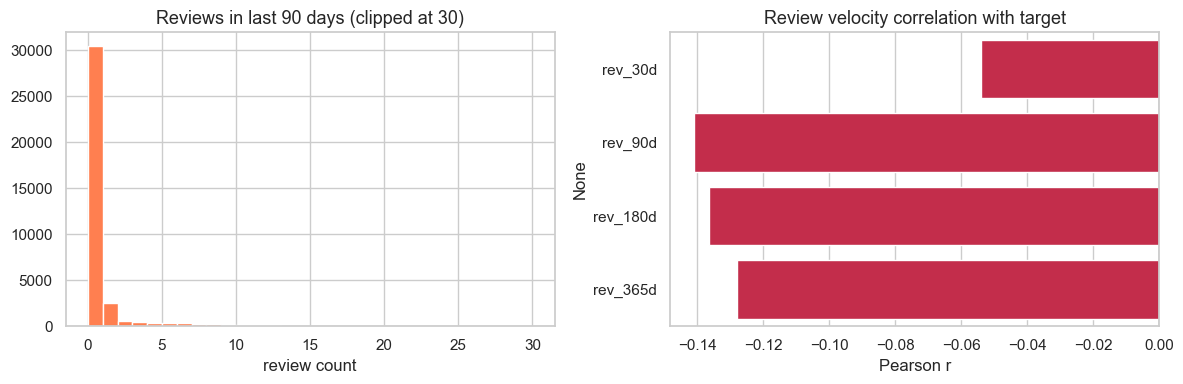

In [110]:
rev_cols = ['rev_30d', 'rev_90d', 'rev_180d', 'rev_365d']
rev_merged = target.merge(listings[['id'] + rev_cols], on='id', how='inner')
rev_corr = rev_merged[rev_cols + ['blocked_days_Q1_2026']].corr()['blocked_days_Q1_2026'].drop('blocked_days_Q1_2026')
print('Correlation of review velocity with target:')
print(rev_corr.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Distribution
rev_merged['rev_90d'].clip(0, 30).hist(bins=30, ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Reviews in last 90 days (clipped at 30)')
axes[0].set_xlabel('review count')
# Correlation bar
sns.barplot(x=rev_corr.values, y=rev_corr.index, ax=axes[1],
            palette=['steelblue' if v >= 0 else 'crimson' for v in rev_corr.values])
axes[1].set_title('Review velocity correlation with target')
axes[1].set_xlabel('Pearson r')
axes[1].axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'review_velocity.png', dpi=120)
plt.show()

## 16. `availability_*` vs Target — Dedicated Analysis

Airbnb pre-computes `availability_30/60/90/365` (number of open days in the next N days as of
the scrape date). These are expected to be among the strongest predictors because
fewer open days = more already booked = higher expected Q1 2026 blocked days.

Correlation with blocked_days_Q1_2026:
availability_30    -0.7361
availability_60    -0.8981
availability_90    -0.9594
availability_365   -0.8583


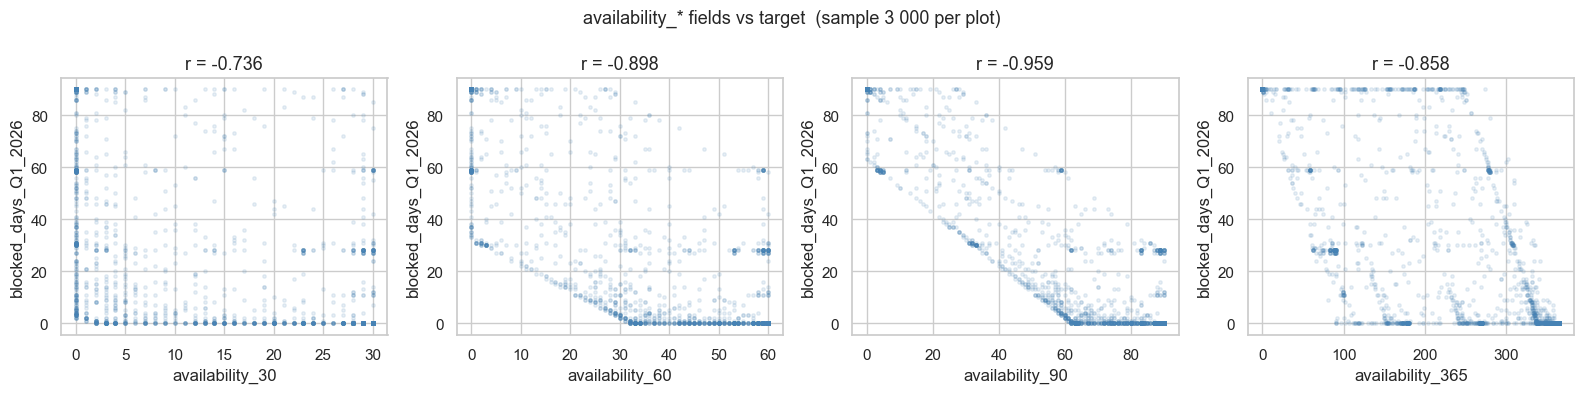

In [111]:
avail_cols = ['availability_30', 'availability_60', 'availability_90', 'availability_365']
avail_cols = [c for c in avail_cols if c in train_df.columns]

# Convert to numeric (they may be strings)
for c in avail_cols:
    train_df[c] = pd.to_numeric(train_df[c], errors='coerce')

avail_corr = train_df[avail_cols + ['blocked_days_Q1_2026']].corr()['blocked_days_Q1_2026'].drop('blocked_days_Q1_2026')
print('Correlation with blocked_days_Q1_2026:')
print(avail_corr.round(4).to_string())

fig, axes = plt.subplots(1, len(avail_cols), figsize=(16, 4))
for ax, col in zip(axes, avail_cols):
    sub = train_df[[col, 'blocked_days_Q1_2026']].dropna()
    sub = sub.sample(min(3000, len(sub)), random_state=RANDOM_STATE)
    ax.scatter(sub[col], sub['blocked_days_Q1_2026'], alpha=0.12, s=6, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('blocked_days_Q1_2026')
    ax.set_title(f'r = {avail_corr.get(col, float("nan")):.3f}')
plt.suptitle('availability_* fields vs target  (sample 3 000 per plot)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'avail_vs_target.png', dpi=120, bbox_inches='tight')
plt.show()

## 17. Key Findings & Next Steps

### Note on Missing Value Handling
Missing values are **not** imputed here. Handling is deferred to modelling pipelines:
- **Tree-based models:** `SimpleImputer(strategy='median', add_indicator=True)` in sklearn Pipeline.
- **XGBoost:** Native missing-value handling (sparsity-aware splitting).
- **MLP:** Median imputation + scaling inside the pipeline.

### Key Findings

1. **Target**: Bimodal distribution — spike at 0 (inactive/long-term listings) + spread toward 60–90 (active short-term). Same heavy-zero shape as the 2016 Kaggle data. Section 5.1's Dec-vs-Jan snapshot comparison shows a real fraction of "blocked" date-observations flip back to available on re-observation — a single-snapshot count can't tell that apart from a real booking, so the target actually used in `02_FeatureEngineering.ipynb` is the clean multi-snapshot rule, not the naive single-snapshot count computed earlier in this notebook.

2. **Strongest metadata predictors**: `availability_30/60/90/365` (negative correlation — fewer open days = more booked) and `estimated_occupancy_l365d` (Airbnb's own backward-looking occupancy estimate). These replace the old `q2_reserved_rate` (r=0.78) as the top signal.

3. **Calendar seasonality**: Q3 2025 (summer) blocking rate higher than Q4 2025. Seasonal calendar features will add value.

4. **Borough effect**: Manhattan and Brooklyn have higher mean blocked days than outer boroughs.

5. **Review velocity** correlates positively with blocked days — listings with more recent reviews are more active.

6. **Price — December 2025 is 100% empty**, and no single Jul-Nov month is complete either (~55-59% each, on a partly different set of listings — see Section 11's union check). Averaging price across all 5 available months recovers more coverage than any one month and adds trend/volatility signal; a neighbourhood-relative price and an explicit `price_missing` flag cover what's still missing. This is a genuine limitation of open crowd-sourced data relative to the complete pricing in the proprietary 2016 Kaggle dataset, and is documented as such in the paper.

7. **18,870 / 36,261 target listings** appear in all 6 training months. ~17,391 have missing calendar data for ≥1 month — accept NaN and let models handle it.

8. **New schema differences from Kaggle**:
   - `available ∈ {t, f}` replaces `Status ∈ {A, B, R}` — can't separate booked from host-blocked from a single snapshot (see Section 5.1).
   - `property_type` is a combined field (e.g., `'Entire rental unit'`) — grouped into 5 categories.
   - `bathrooms_text` requires regex parsing → `bathrooms_num` + `bath_is_shared`.
   - `amenities` is a JSON list → binary flags for WiFi, Kitchen, AC, etc.

### Decisions for `02_FeatureEngineering.ipynb`

| Decision | Choice |
|---|---|
| Metadata source | December 2025 `listings.csv` (85 cols) |
| Price source | **5-month average** (Jul-Nov 2025: mean/std/cv/trend) + implied `rev/occ` fallback + neighbourhood-relative price + `price_missing` flag |
| Listing pool | All in December 2025 calendar (~36 261); NaN for missing months |
| Calendar features | Each month's scrape filtered to its own dates (Q3+Q4 2025) |
| Calendar price feature | Skip — use listing-level price instead |
| `property_type` encoding | Group → 5 classes → one-hot |
| `amenities` | 14 binary flags |
| `bathrooms_text` | `bathrooms_num` float + `bath_is_shared` flag |
| Train/test split | 80/20 random on all labeled listings |
| Target column | `blocked_days_Q1_2026` (replaces `NumReserveDays2016Q3`) — built from a **clean multi-snapshot rule** (Oct 2025-Mar 2026 calendars: booked only if ever seen available, last-observed unavailable, seen in >=2 snapshots), not the naive single-December-snapshot count explored earlier in this notebook |